In [2]:
import json
import numpy as np
import math
from statistics import NormalDist
from typing import Any
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# read csv
dfs = {}
for day in [-2, -1, 0]:
    df = pd.read_csv(
        f'/Users/weifengfu/Documents/GitHub/imc-prosperity-3/data/round1/prices_round_1_day_{day}.csv',
        sep=';'
    )
    dfs[day] = df[df['mid_price'] > 0]  # filter out rows with mid_price <= 0
    print(dfs[day].groupby('product')['mid_price'].std())

product
ASH_COATED_OSMIUM         5.219914
INTARIAN_PEPPER_ROOT    288.722378
Name: mid_price, dtype: float64
product
ASH_COATED_OSMIUM         4.450045
INTARIAN_PEPPER_ROOT    288.669011
Name: mid_price, dtype: float64
product
ASH_COATED_OSMIUM         5.683730
INTARIAN_PEPPER_ROOT    288.730986
Name: mid_price, dtype: float64


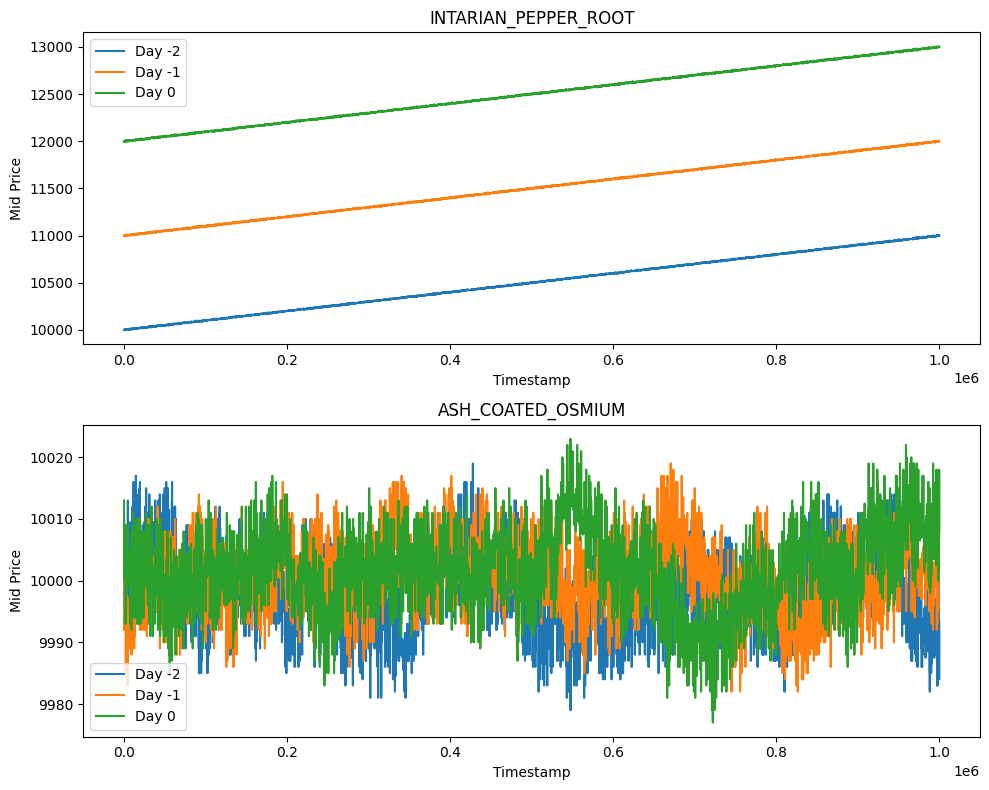

In [4]:
# plotting
fig, axes = plt.subplots(2, 1, figsize=(10, 8))

products = ['INTARIAN_PEPPER_ROOT', 'ASH_COATED_OSMIUM']

for ax, product in zip(axes, products):
    for day, df in dfs.items():
        product_df = df[df['product'] == product]
        ax.plot(product_df['timestamp'], product_df['mid_price'], label=f'Day {day}')
    ax.set_title(product)
    ax.legend()
    ax.set_xlabel('Timestamp')
    ax.set_ylabel('Mid Price')

plt.tight_layout()
plt.show()


In [5]:
# detrending the price series for intarian pepper root
for day, df in dfs.items():
    product_df = df[df['product'] == 'INTARIAN_PEPPER_ROOT'].copy()
    
    coeffs = np.polyfit(product_df['timestamp'], product_df['mid_price'], 1)
    product_df['trend'] = np.polyval(coeffs, product_df['timestamp'])
    product_df['residual'] = product_df['mid_price'] - product_df['trend']
    
    print(f"Day {day}: slope={coeffs[0]:.6f}, intercept={coeffs[1]:.2f}, residual std={product_df['residual'].std():.4f}")

Day -2: slope=0.001000, intercept=9999.98, residual std=2.0095
Day -1: slope=0.001000, intercept=10999.97, residual std=2.2206
Day 0: slope=0.001000, intercept=11999.95, residual std=2.3599


In [6]:
# Combine all days
all_days = pd.concat(dfs.values())
product_df = all_days[all_days['product'] == 'INTARIAN_PEPPER_ROOT']
coeffs = np.polyfit(product_df['timestamp'], product_df['mid_price'], 1)
print(f"Combined slope: {coeffs[0]:.6f}, intercept: {coeffs[1]:.2f}")


Combined slope: 0.001001, intercept: 10999.37


In [7]:
trades = pd.read_csv("/Users/weifengfu/Documents/GitHub/imc-prosperity-3/data/round1/prices_round_1_day_-1.csv", sep=";")

# See what columns exist
print(trades.columns.tolist())
print(trades.head(10))

['day', 'timestamp', 'product', 'bid_price_1', 'bid_volume_1', 'bid_price_2', 'bid_volume_2', 'bid_price_3', 'bid_volume_3', 'ask_price_1', 'ask_volume_1', 'ask_price_2', 'ask_volume_2', 'ask_price_3', 'ask_volume_3', 'mid_price', 'profit_and_loss']
   day  timestamp               product  bid_price_1  bid_volume_1  \
0   -1          0  INTARIAN_PEPPER_ROOT      10991.0          15.0   
1   -1          0     ASH_COATED_OSMIUM          NaN           NaN   
2   -1        100     ASH_COATED_OSMIUM       9984.0          11.0   
3   -1        100  INTARIAN_PEPPER_ROOT      10994.0           9.0   
4   -1        200     ASH_COATED_OSMIUM       9985.0          15.0   
5   -1        200  INTARIAN_PEPPER_ROOT      10994.0          10.0   
6   -1        300  INTARIAN_PEPPER_ROOT          NaN           NaN   
7   -1        300     ASH_COATED_OSMIUM       9985.0          11.0   
8   -1        400  INTARIAN_PEPPER_ROOT      10992.0          20.0   
9   -1        400     ASH_COATED_OSMIUM       9985

In [9]:
pepper = trades[trades['product'] == 'INTARIAN_PEPPER_ROOT'].copy()

# Who trades most frequently?
print(pepper['buyer'].value_counts())
print(pepper['seller'].value_counts())

KeyError: 'buyer'